# Forward Options - Comprehensive Tutorial

**Options on Forward Contracts using the Black76 Model**

This tutorial provides a comprehensive guide to pricing and analyzing forward options, with a focus on FX forward options.

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Forward Price Fundamentals](#2-forward-price-fundamentals)
3. [Black76 Model](#3-black76-model)
4. [FX Forward Options](#4-fx-forward-options)
5. [Greeks Analysis](#5-greeks-analysis)
6. [Forward vs Spot Options](#6-forward-vs-spot-options)
7. [Hedging Considerations](#7-hedging-considerations)
8. [Advanced Topics](#8-advanced-topics)

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
import math
from datetime import date

# QuantStrata imports - Market Data
from src.marketdata.core.ids import MarketId
from src.marketdata.core.market import Market
from src.marketdata.core.interfaces import Quote
from src.marketdata.surfaces.vol_surface import FlatVolSurface
from src.marketdata.curves.term_structure import FlatZeroRateCurve

# FX Forward Options
from src.instruments.fx.options.forward import (
    EuropeanFxForwardOption,
    EuropeanFxForwardOptionSimple,
)
from src.pricers.fx.european_b76 import (
    FxForwardOptionBlack76Pricer,
    FxForwardOptionBlack76PricerSimple,
)

# FX Spot Options (for comparison)
from src.instruments.fx.options.vanilla import EuropeanFxVanillaOption
from src.pricers.fx.european_bsm import FxEuropeanVanillaBsmPricer

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
})

print("Imports successful!")

Imports successful!


---

## 1. Introduction

### What is a Forward Option?

A **forward option** is an option where the underlying is a forward contract, not the spot price. Key characteristics:

| Aspect | Spot Option | Forward Option |
|--------|-------------|----------------|
| Underlying | Spot price S | Forward price F |
| Model | Black-Scholes-Merton | Black76 |
| Delta | dV/dS | dV/dF |
| No-drift | Requires cost-of-carry | Forward is martingale |

### When to Use Forward Options

- **OTC FX markets**: Forward volatility is often quoted directly
- **Deferred settlement**: Option expiry differs from settlement
- **Forward-starting structures**: Cliquets, forward-start options
- **Hedging forward exposures**: Natural hedge for forward positions

---

## 2. Forward Price Fundamentals

### FX Forward Rate

In [2]:
# FX Forward Rate Calculation
def fx_forward(spot, r_dom, r_for, T):
    """
    Calculate FX forward rate.
    
    F = S × exp((r_d - r_f) × T)
    
    Parameters
    ----------
    spot : float
        Spot rate (domestic per foreign)
    r_dom : float
        Domestic risk-free rate
    r_for : float
        Foreign risk-free rate
    T : float
        Time to delivery in years
    """
    return spot * math.exp((r_dom - r_for) * T)

# EURUSD example
spot = 1.10
r_usd = 0.05  # 5% USD rate
r_eur = 0.03  # 3% EUR rate

print("EURUSD Forward Rates:")
print(f"{'Tenor':<10} {'Forward':>10} {'Forward Points':>15}")
print("-" * 35)

tenors = [0.25, 0.5, 1.0, 2.0, 5.0]
for T in tenors:
    F = fx_forward(spot, r_usd, r_eur, T)
    points = (F - spot) * 10000  # Forward points (pips)
    print(f"{T:>5.2f}Y{'':<4} {F:>10.4f} {points:>+14.1f}")

print(f"\nNote: USD rates > EUR rates → EURUSD trades at a premium (F > S)")

EURUSD Forward Rates:
Tenor         Forward  Forward Points
-----------------------------------
 0.25Y         1.1055          +55.1
 0.50Y         1.1111         +110.6
 1.00Y         1.1222         +222.2
 2.00Y         1.1449         +448.9
 5.00Y         1.2157        +1156.9

Note: USD rates > EUR rates → EURUSD trades at a premium (F > S)


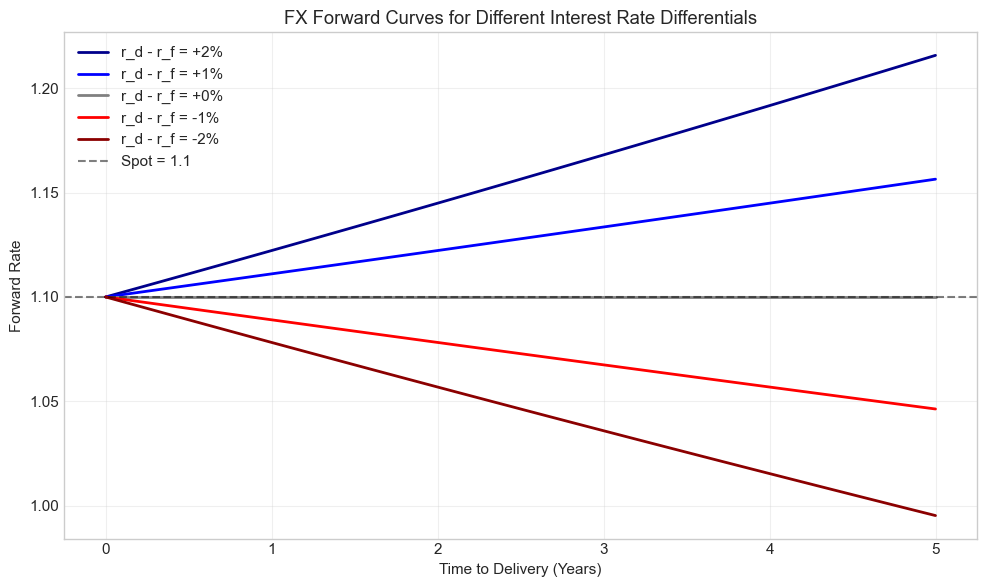

In [3]:
# Visualize forward curves for different rate differentials
tenors = np.linspace(0, 5, 51)

fig, ax = plt.subplots(figsize=(10, 6))

rate_diffs = [0.02, 0.01, 0.0, -0.01, -0.02]
colors = ['darkblue', 'blue', 'gray', 'red', 'darkred']

for diff, color in zip(rate_diffs, colors):
    forwards = [fx_forward(spot, 0.03 + diff, 0.03, T) for T in tenors]
    label = f'r_d - r_f = {diff:+.0%}'
    ax.plot(tenors, forwards, color=color, label=label, linewidth=2)

ax.axhline(spot, color='black', linestyle='--', alpha=0.5, label=f'Spot = {spot}')
ax.set_xlabel('Time to Delivery (Years)')
ax.set_ylabel('Forward Rate')
ax.set_title('FX Forward Curves for Different Interest Rate Differentials')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Black76 Model

### Model Dynamics

Under the Black76 model, the forward price follows:

$$dF = \sigma F \, dW$$

**Key insight**: No drift! The forward price is a martingale under the T-forward measure.

### Pricing Formulas

$$C = DF \cdot [F \cdot N(d_1) - K \cdot N(d_2)]$$
$$P = DF \cdot [K \cdot N(-d_2) - F \cdot N(-d_1)]$$

Where:
- $d_1 = \frac{\ln(F/K) + \sigma^2 T / 2}{\sigma \sqrt{T}}$
- $d_2 = d_1 - \sigma \sqrt{T}$
- $DF = e^{-r_d T}$ (discount factor)

In [4]:
# Black76 formula implementation (educational)
from scipy.stats import norm

def black76_call(F, K, T, r, sigma):
    """
    Black76 call price.
    
    Parameters
    ----------
    F : float
        Forward price
    K : float
        Strike price
    T : float
        Time to expiry
    r : float
        Discount rate
    sigma : float
        Volatility
    """
    if T <= 0:
        return max(F - K, 0) * math.exp(-r * T)
    
    d1 = (math.log(F / K) + 0.5 * sigma**2 * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    
    df = math.exp(-r * T)
    return df * (F * norm.cdf(d1) - K * norm.cdf(d2))

def black76_put(F, K, T, r, sigma):
    """Black76 put price."""
    if T <= 0:
        return max(K - F, 0) * math.exp(-r * T)
    
    d1 = (math.log(F / K) + 0.5 * sigma**2 * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    
    df = math.exp(-r * T)
    return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

# Example
F = fx_forward(1.10, 0.05, 0.03, 1.0)  # 1Y forward
K = 1.12
T = 1.0
r = 0.05
sigma = 0.08

call_price = black76_call(F, K, T, r, sigma)
put_price = black76_put(F, K, T, r, sigma)

print(f"Black76 Pricing Example:")
print(f"  Forward (1Y): {F:.4f}")
print(f"  Strike:       {K:.4f}")
print(f"  Vol:          {sigma:.0%}")
print(f"  Discount:     {r:.1%}")
print(f"")
print(f"  Call Price:   {call_price:.6f}")
print(f"  Put Price:    {put_price:.6f}")
print(f"")
print(f"Put-Call Parity Check:")
print(f"  C - P = {call_price - put_price:.6f}")
print(f"  DF(F-K) = {math.exp(-r*T) * (F - K):.6f}")

Black76 Pricing Example:
  Forward (1Y): 1.1222
  Strike:       1.1200
  Vol:          8%
  Discount:     5.0%

  Call Price:   0.035094
  Put Price:    0.032980

Put-Call Parity Check:
  C - P = 0.002113
  DF(F-K) = 0.002113


---

## 4. FX Forward Options

### 4.1 Market Setup

In [5]:
# Define MarketIds
SPOT_ID = MarketId("FX", "SPOT", "EURUSD", (("dom", "USD"), ("for", "EUR")))
VOL_ID = MarketId("FX", "VOL", "EURUSD", (("dom", "USD"), ("for", "EUR")))
USD_CURVE_ID = MarketId("IR", "CURVE", "USD.OIS", (("ccy", "USD"),))
EUR_CURVE_ID = MarketId("IR", "CURVE", "EUR.OIS", (("ccy", "EUR"),))

# Create market
market = Market(
    asof="2026-01-15",
    quotes={SPOT_ID: Quote(value=1.10)},
    curves={
        USD_CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=0.05),
        EUR_CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=0.03),
    },
    vols={VOL_ID: FlatVolSurface(sigma=0.08)},
)

# Calculate forward
forward_1y = 1.10 * math.exp((0.05 - 0.03) * 1.0)

print("Market Setup:")
print(f"  Spot:        {market.quote(SPOT_ID):.4f}")
print(f"  Forward(1Y): {forward_1y:.4f}")
print(f"  Vol:         {market.vol_surface(VOL_ID).vol(1.0, 1.10):.0%}")
print(f"  USD Rate:    {market.curve(USD_CURVE_ID).zero_rate(1.0):.1%}")
print(f"  EUR Rate:    {market.curve(EUR_CURVE_ID).zero_rate(1.0):.1%}")

Market Setup:
  Spot:        1.1000
  Forward(1Y): 1.1222
  Vol:         8%
  USD Rate:    5.0%
  EUR Rate:    3.0%


### 4.2 Pricing FX Forward Options

In [6]:
# Create FX forward option
fwd_call = EuropeanFxForwardOption(
    option_type="call",
    notional=1_000_000,      # EUR 1M
    strike=1.12,             # Strike forward rate
    expiry=1.0,              # 1 year option
    forward_expiry=1.0,      # Same as option expiry
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

fwd_put = EuropeanFxForwardOption(
    option_type="put",
    notional=1_000_000,
    strike=1.12,
    expiry=1.0,
    forward_expiry=1.0,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Price
pricer = FxForwardOptionBlack76Pricer()

call_pv = pricer.price(fwd_call, market)
put_pv = pricer.price(fwd_put, market)

print("FX Forward Options (K=1.12, T=1Y, Notional=EUR 1M):")
print(f"  Call PV: ${call_pv:,.2f}")
print(f"  Put PV:  ${put_pv:,.2f}")

# Put-call parity check
df = math.exp(-0.05 * 1.0)
expected_diff = df * (forward_1y - 1.12) * 1_000_000
actual_diff = call_pv - put_pv

print(f"\nPut-Call Parity:")
print(f"  C - P = ${actual_diff:,.2f}")
print(f"  DF(F-K) × Notional = ${expected_diff:,.2f}")
print(f"  Match: {np.isclose(actual_diff, expected_diff, rtol=1e-6)}")

FX Forward Options (K=1.12, T=1Y, Notional=EUR 1M):
  Call PV: $35,093.56
  Put PV:  $32,980.43

Put-Call Parity:
  C - P = $2,113.13
  DF(F-K) × Notional = $2,113.13
  Match: True


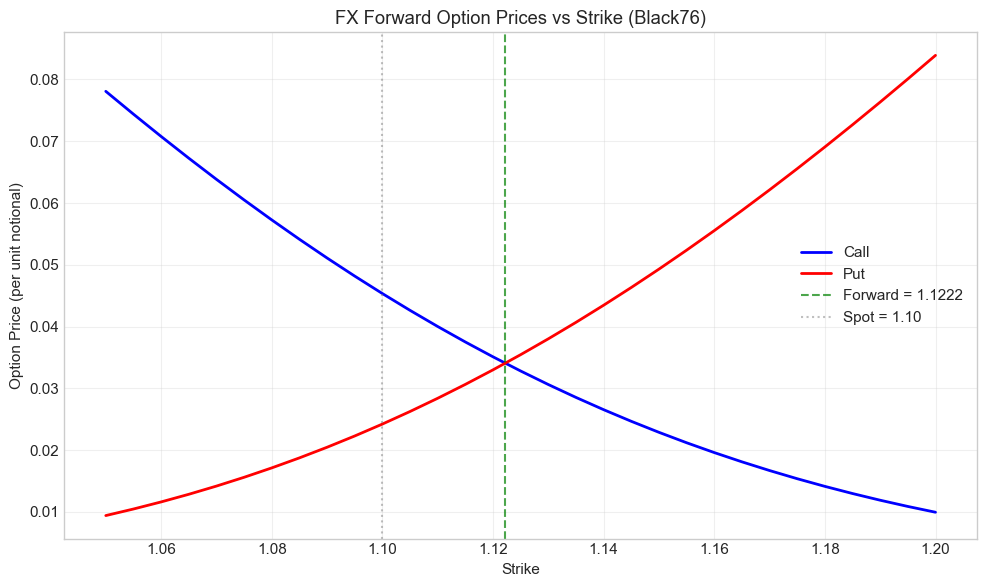

In [7]:
# Price across strikes
strikes = np.linspace(1.05, 1.20, 31)
call_prices = []
put_prices = []

for K in strikes:
    call = EuropeanFxForwardOption(
        option_type="call", notional=1.0, strike=K, expiry=1.0, forward_expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    put = EuropeanFxForwardOption(
        option_type="put", notional=1.0, strike=K, expiry=1.0, forward_expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    call_prices.append(pricer.price(call, market))
    put_prices.append(pricer.price(put, market))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes, call_prices, 'b-', label='Call', linewidth=2)
ax.plot(strikes, put_prices, 'r-', label='Put', linewidth=2)
ax.axvline(forward_1y, color='green', linestyle='--', alpha=0.7, label=f'Forward = {forward_1y:.4f}')
ax.axvline(1.10, color='gray', linestyle=':', alpha=0.5, label='Spot = 1.10')

ax.set_xlabel('Strike')
ax.set_ylabel('Option Price (per unit notional)')
ax.set_title('FX Forward Option Prices vs Strike (Black76)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Greeks Analysis

### 5.1 Forward Delta vs Spot Delta

In [8]:
# Get Greeks
call_greeks = pricer.greeks(fwd_call, market)
put_greeks = pricer.greeks(fwd_put, market)

print("Greeks for FX Forward Options (K=1.12, T=1Y, Notional=EUR 1M):")
print(f"\n{'Greek':<18} {'Call':>15} {'Put':>15}")
print("-" * 50)

for greek in ['delta_forward', 'delta_spot', 'gamma', 'vega', 'theta', 'rho_domestic', 'rho_foreign']:
    call_val = call_greeks[greek]
    put_val = put_greeks[greek]
    print(f"{greek:<18} {call_val:>15,.2f} {put_val:>15,.2f}")

Greeks for FX Forward Options (K=1.12, T=1Y, Notional=EUR 1M):

Greek                         Call             Put
--------------------------------------------------
delta_forward           500,176.32     -451,053.10
delta_spot              510,280.55     -460,164.98
gamma                 4,218,090.09    4,218,090.09
vega                    424,974.61      424,974.61
theta                   -15,244.31      -15,349.96
rho_domestic           -596,402.17      473,201.05
rho_foreign             561,308.61     -506,181.48


In [9]:
# Understand the delta relationship
print("Delta Relationship:")
print(f"\nFor calls:")
print(f"  Delta Forward: {call_greeks['delta_forward']:,.0f}")
print(f"  Delta Spot:    {call_greeks['delta_spot']:,.0f}")
print(f"  Ratio:         {call_greeks['delta_spot'] / call_greeks['delta_forward']:.4f}")

# Expected ratio = exp((r_d - r_f) * T) = DF_for / DF_dom
expected_ratio = math.exp((0.05 - 0.03) * 1.0)
print(f"  Expected:      {expected_ratio:.4f} = exp((r_d - r_f) × T)")

print(f"\nInterpretation:")
print(f"  - Delta Forward: Sensitivity to forward rate")
print(f"  - Delta Spot: Sensitivity to spot rate (for hedging with spot)")
print(f"  - Since USD rate > EUR rate, spot delta > forward delta")

Delta Relationship:

For calls:
  Delta Forward: 500,176
  Delta Spot:    510,281
  Ratio:         1.0202
  Expected:      1.0202 = exp((r_d - r_f) × T)

Interpretation:
  - Delta Forward: Sensitivity to forward rate
  - Delta Spot: Sensitivity to spot rate (for hedging with spot)
  - Since USD rate > EUR rate, spot delta > forward delta


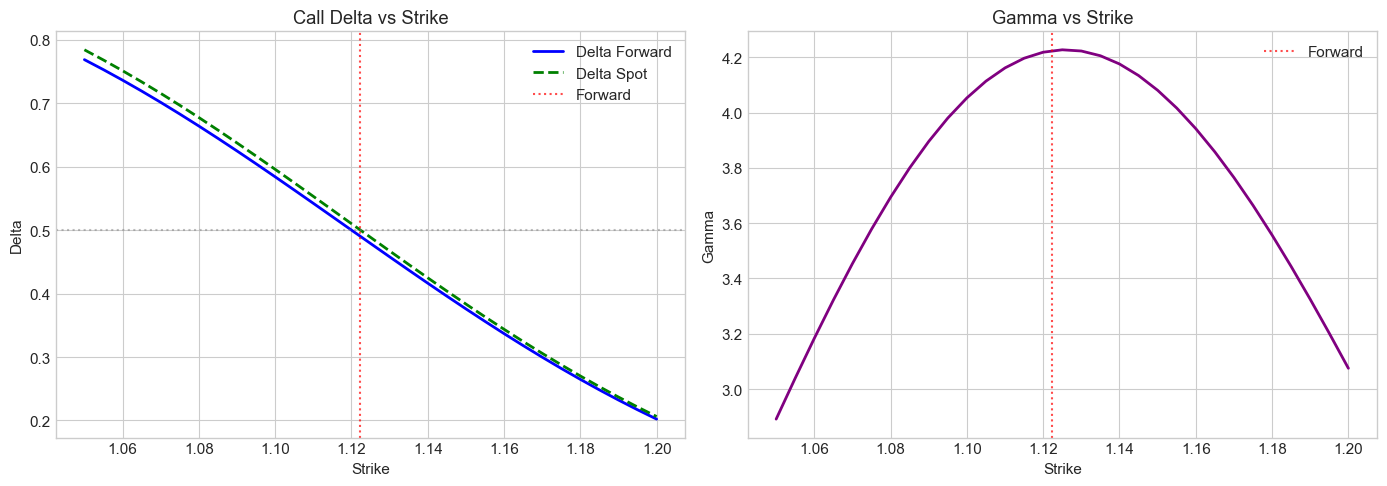

In [10]:
# Delta across strikes
strikes = np.linspace(1.05, 1.20, 31)
call_delta_fwd = []
call_delta_spot = []
gammas = []

for K in strikes:
    call = EuropeanFxForwardOption(
        option_type="call", notional=1.0, strike=K, expiry=1.0, forward_expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    g = pricer.greeks(call, market)
    call_delta_fwd.append(g['delta_forward'])
    call_delta_spot.append(g['delta_spot'])
    gammas.append(g['gamma'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, call_delta_fwd, 'b-', label='Delta Forward', linewidth=2)
ax.plot(strikes, call_delta_spot, 'g--', label='Delta Spot', linewidth=2)
ax.axvline(forward_1y, color='red', linestyle=':', alpha=0.7, label='Forward')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Delta')
ax.set_title('Call Delta vs Strike')
ax.legend()

ax = axes[1]
ax.plot(strikes, gammas, 'purple', linewidth=2)
ax.axvline(forward_1y, color='red', linestyle=':', alpha=0.7, label='Forward')
ax.set_xlabel('Strike')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Strike')
ax.legend()

plt.tight_layout()
plt.show()

---

## 6. Forward vs Spot Options

### Comparison

In [11]:
# Create equivalent spot option
spot_call = EuropeanFxVanillaOption(
    option_type="call",
    notional=1_000_000,
    strike=1.12,
    expiry=1.0,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Price both
bsm_pricer = FxEuropeanVanillaBsmPricer()

spot_call_pv = bsm_pricer.price(spot_call, market)
fwd_call_pv = pricer.price(fwd_call, market)

spot_greeks = bsm_pricer.greeks(spot_call, market)
fwd_greeks = pricer.greeks(fwd_call, market)

print("Spot Option vs Forward Option (K=1.12, T=1Y):")
print(f"\n{'Metric':<20} {'Spot Option':>15} {'Forward Option':>15}")
print("-" * 55)
print(f"{'PV':<20} ${spot_call_pv:>13,.2f} ${fwd_call_pv:>13,.2f}")
print(f"{'Delta':<20} {spot_greeks['delta']:>15,.0f} {fwd_greeks['delta_spot']:>15,.0f}")
print(f"{'Gamma':<20} {spot_greeks['gamma']:>15,.2f} {fwd_greeks['gamma']:>15,.2f}")
print(f"{'Vega':<20} {spot_greeks['vega']:>15,.2f} {fwd_greeks['vega']:>15,.2f}")

print(f"\nNote: Prices should be identical (no-arbitrage)")
print(f"Price difference: ${abs(spot_call_pv - fwd_call_pv):.2f}")

Spot Option vs Forward Option (K=1.12, T=1Y):

Metric                   Spot Option  Forward Option
-------------------------------------------------------
PV                   $    35,093.56 $    35,093.56
Delta                        510,281         510,281
Gamma                   4,390,233.61    4,218,090.09
Vega                      424,974.61      424,974.61

Note: Prices should be identical (no-arbitrage)
Price difference: $0.00


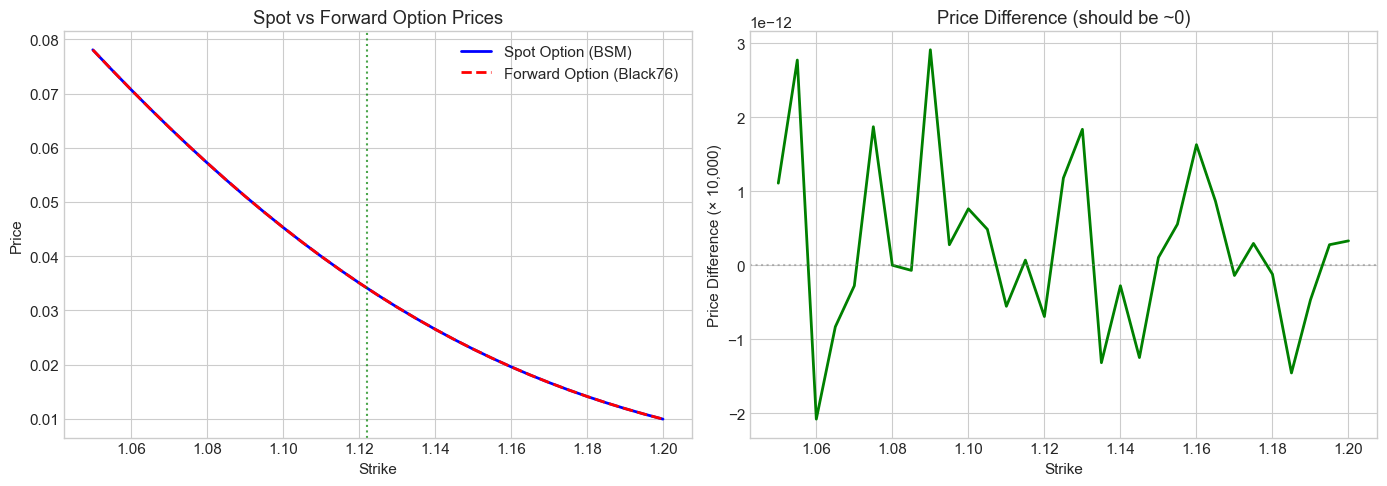

Max price difference: 0.00000000 (numerical precision)


In [12]:
# Compare prices across strikes
strikes = np.linspace(1.05, 1.20, 31)
spot_prices = []
fwd_prices = []

for K in strikes:
    spot_opt = EuropeanFxVanillaOption(
        option_type="call", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    fwd_opt = EuropeanFxForwardOption(
        option_type="call", notional=1.0, strike=K, expiry=1.0, forward_expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    spot_prices.append(bsm_pricer.price(spot_opt, market))
    fwd_prices.append(pricer.price(fwd_opt, market))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, spot_prices, 'b-', label='Spot Option (BSM)', linewidth=2)
ax.plot(strikes, fwd_prices, 'r--', label='Forward Option (Black76)', linewidth=2)
ax.axvline(forward_1y, color='green', linestyle=':', alpha=0.7)
ax.set_xlabel('Strike')
ax.set_ylabel('Price')
ax.set_title('Spot vs Forward Option Prices')
ax.legend()

ax = axes[1]
price_diff = np.array(spot_prices) - np.array(fwd_prices)
ax.plot(strikes, price_diff * 10000, 'g-', linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Price Difference (× 10,000)')
ax.set_title('Price Difference (should be ~0)')

plt.tight_layout()
plt.show()

print(f"Max price difference: {max(abs(price_diff)):.8f} (numerical precision)")

---

## 7. Hedging Considerations

### Spot Hedge vs Forward Hedge

In [13]:
print("Hedging a Long Call Position:")
print(f"\nPosition: Long 1M EUR call, K=1.12, T=1Y")
print(f"\nOption A: Hedge with Spot")
print(f"  Sell {fwd_greeks['delta_spot']:,.0f} EUR spot")
print(f"  Financing: Need to borrow USD (at {0.05:.1%}) to fund EUR position")
print(f"\nOption B: Hedge with Forward")
print(f"  Sell {fwd_greeks['delta_forward']:,.0f} EUR 1Y forward")
print(f"  No financing: Forward requires no upfront cash")

print(f"\n" + "="*60)
print(f"Key Difference:")
print(f"  Spot hedge amount > Forward hedge amount")
print(f"  Because: You need more spot to replicate the forward exposure")
print(f"  Ratio: {fwd_greeks['delta_spot'] / fwd_greeks['delta_forward']:.4f} = exp((r_d - r_f) × T)")

Hedging a Long Call Position:

Position: Long 1M EUR call, K=1.12, T=1Y

Option A: Hedge with Spot
  Sell 510,281 EUR spot
  Financing: Need to borrow USD (at 5.0%) to fund EUR position

Option B: Hedge with Forward
  Sell 500,176 EUR 1Y forward
  No financing: Forward requires no upfront cash

Key Difference:
  Spot hedge amount > Forward hedge amount
  Because: You need more spot to replicate the forward exposure
  Ratio: 1.0202 = exp((r_d - r_f) × T)


---

## 8. Advanced Topics

### 8.1 Simple Pricer (Direct Forward Input)

In [14]:
# When forward rate is directly observable
simple_call = EuropeanFxForwardOptionSimple(
    option_type="call",
    notional=1_000_000,
    strike=1.12,
    expiry=1.0,
    forward_rate=forward_1y,        # Observable forward
    vol=0.08,                       # Forward vol
    discount_factor=math.exp(-0.05),  # USD discount factor
)

simple_pricer = FxForwardOptionBlack76PricerSimple()
simple_pv = simple_pricer.price(simple_call)
simple_greeks = simple_pricer.greeks(simple_call)

print("Simple Pricer (Direct Forward Input):")
print(f"  Forward Rate: {forward_1y:.4f}")
print(f"  Strike:       1.12")
print(f"  Vol:          8%")
print(f"  DF:           {math.exp(-0.05):.4f}")
print(f"\n  Call PV: ${simple_pv:,.2f}")
print(f"\n  Comparison with full pricer: ${fwd_call_pv:,.2f}")
print(f"  Match: {np.isclose(simple_pv, fwd_call_pv, rtol=1e-6)}")

Simple Pricer (Direct Forward Input):
  Forward Rate: 1.1222
  Strike:       1.12
  Vol:          8%
  DF:           0.9512

  Call PV: $35,093.56

  Comparison with full pricer: $35,093.56
  Match: True


### 8.2 Volatility Sensitivity

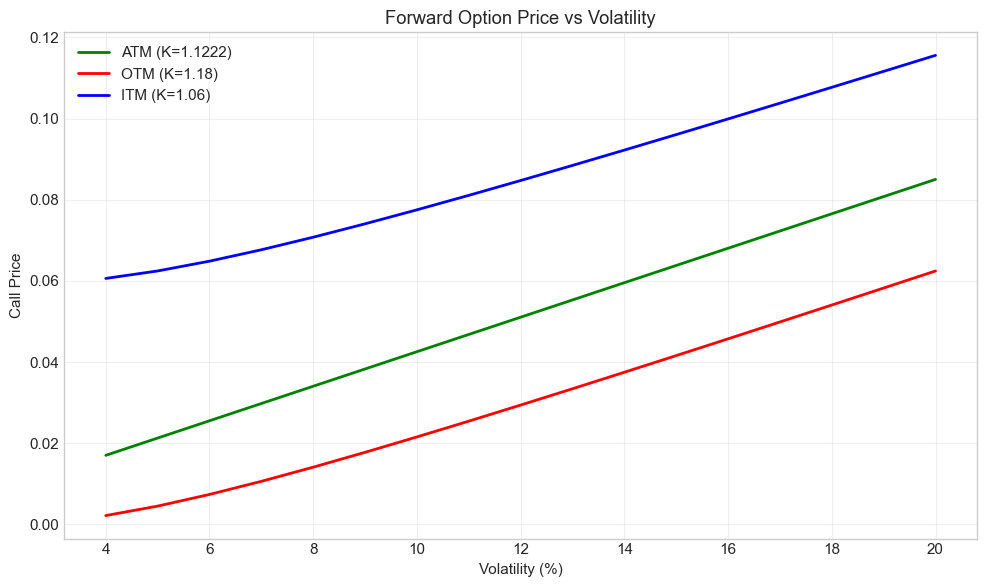

Note: ATM options have highest vega (price sensitivity to vol)


In [15]:
# Price sensitivity to volatility
vols = np.linspace(0.04, 0.20, 17)
atm_prices = []
otm_prices = []
itm_prices = []

for sigma in vols:
    mkt = Market(
        asof="2026-01-15",
        quotes={SPOT_ID: Quote(value=1.10)},
        curves={
            USD_CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=0.05),
            EUR_CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=0.03),
        },
        vols={VOL_ID: FlatVolSurface(sigma=sigma)},
    )
    
    for strike, prices in [(forward_1y, atm_prices), (1.18, otm_prices), (1.06, itm_prices)]:
        opt = EuropeanFxForwardOption(
            option_type="call", notional=1.0, strike=strike, expiry=1.0, forward_expiry=1.0,
            spot_id=SPOT_ID, vol_id=VOL_ID,
            domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
        )
        prices.append(pricer.price(opt, mkt))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(vols * 100, atm_prices, 'g-', label=f'ATM (K={forward_1y:.4f})', linewidth=2)
ax.plot(vols * 100, otm_prices, 'r-', label='OTM (K=1.18)', linewidth=2)
ax.plot(vols * 100, itm_prices, 'b-', label='ITM (K=1.06)', linewidth=2)

ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Call Price')
ax.set_title('Forward Option Price vs Volatility')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: ATM options have highest vega (price sensitivity to vol)")

---

## Summary

### Key Concepts

| Concept | Description |
|---------|-------------|
| **Forward Price** | F = S × exp((r_d - r_f) × T) |
| **Black76** | Forward is martingale → no drift term |
| **Delta Forward** | Sensitivity to forward rate |
| **Delta Spot** | = Delta Forward × exp((r_d - r_f) × T) |
| **Price Equivalence** | Spot option = Forward option (same strike/expiry) |

### When to Use

- Forward options when forward volatility is quoted directly
- Black76 when underlying is naturally a forward (FRAs, futures)
- Spot options when hedging with spot market

### Related Documentation

- [Black76 Model](../../reference/models/black76.md)
- [Forward Options Guide](../../guides/instruments/forward_options.md)
- [FX Options Pricing](fx_options_pricing.ipynb)